# POI Service Network Gaps

Identify network nodes with low access to nearby service opportunities.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by urban analytics notebooks using OSMnx and NetworkX for service accessibility.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import folium
import osmnx as ox
from shapely.geometry import LineString
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
nodes = pd.read_csv(DATA / 'nodes.csv')
edges = pd.read_csv(DATA / 'edges.csv')
print({'nodes': len(nodes), 'edges': len(edges), 'osmnx_version': ox.__version__})
display(nodes.head())


{'nodes': 49, 'edges': 84, 'osmnx_version': '2.1.0'}


,node,x,y,jobs
0,N0_0,118.700,31.92,46
1,N0_1,118.718,31.92,64
2,N0_2,118.736,31.92,162
3,N0_3,118.754,31.92,215
4,N0_4,118.772,31.92,217


In [2]:
G = nx.Graph()
for row in nodes.itertuples():
    G.add_node(row.node, x=row.x, y=row.y, jobs=row.jobs)
for row in edges.itertuples():
    G.add_edge(row.u, row.v, weight=row.minutes)
centrality = nx.betweenness_centrality(G, weight='weight')
access = {}
for node in G.nodes:
    lengths = nx.single_source_dijkstra_path_length(G, node, cutoff=18, weight='weight')
    access[node] = sum(G.nodes[n]['jobs'] for n in lengths)
nodes['betweenness'] = nodes['node'].map(centrality)
nodes['jobs_18min'] = nodes['node'].map(access)
display(nodes.sort_values('jobs_18min', ascending=False).head(8))


,node,x,y,jobs,betweenness,jobs_18min
24,N3_3,118.754,31.962,73,0.200355,4982
31,N4_3,118.754,31.976,208,0.266844,4589
25,N3_4,118.772,31.962,57,0.123227,4500
23,N3_2,118.736,31.962,31,0.253546,4291
17,N2_3,118.754,31.948,205,0.054078,4184
30,N4_2,118.736,31.976,38,0.109929,4138
32,N4_4,118.772,31.976,185,0.209220,4106
38,N5_3,118.754,31.990,23,0.174645,4032


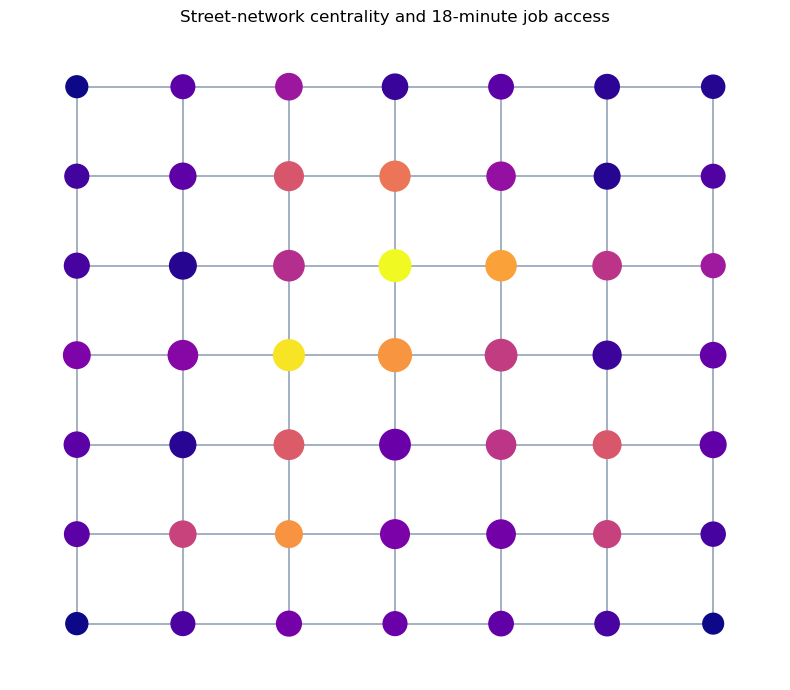

In [3]:
pos = {row.node: (row.x, row.y) for row in nodes.itertuples()}
fig, ax = plt.subplots(figsize=(8, 7))
nx.draw_networkx_edges(G, pos, ax=ax, width=1.2, edge_color='#94a3b8')
size = 60 + nodes.set_index('node').loc[list(G.nodes), 'jobs_18min'].to_numpy() / 10
nx.draw_networkx_nodes(G, pos, node_size=size, node_color=list(centrality.values()), cmap='plasma', ax=ax)
ax.set_title('Street-network centrality and 18-minute job access')
ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUT / 'network_access.png', dpi=160)
plt.show()


In [4]:
center = [nodes.y.mean(), nodes.x.mean()]
m = folium.Map(location=center, zoom_start=13, tiles='CartoDB positron')
node_lookup = nodes.set_index('node')
for row in edges.itertuples():
    a = node_lookup.loc[row.u]
    b = node_lookup.loc[row.v]
    folium.PolyLine([[a.y, a.x], [b.y, b.x]], color='#64748b', weight=2, opacity=0.7).add_to(m)
for row in nodes.itertuples():
    folium.CircleMarker([row.y, row.x], radius=3 + row.jobs_18min / 250, color='#2563eb', fill=True, fill_opacity=0.75, popup=f'{row.node}: jobs in 18 min={row.jobs_18min}').add_to(m)
m.save(OUT / 'network_access_map.html')
display(m)
